# Etapa 4 — Padrões Frequentes, Detecção de Anomalias e Conclusões

Fechamos o trabalho sobre a base de restaurantes do iFood (fev/2021). Partindo do dataset tratado na Etapa 1, dos atributos escolhidos na Etapa 2 e dos clusters da Etapa 3, aqui fazemos:

1. **Mineração de padrões frequentes**: Apriori e FP-Growth, com suporte, confiança e lift;
2. **Detecção de anomalias por distância**: distância ao centróide, k-NN e LOF, combinados por consenso;
3. **Interpretação e conclusões**: descrição dos padrões, relação com os clusters, implicações, limitações e justificativa de todas as escolhas.

In [22]:
import sys
import os
from pathlib import Path

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

try:
    import google.colab
    _in_colab = True
except ImportError:
    _in_colab = False

_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir()),
    None
)

if _root is None:
    if not _in_colab:
        raise RuntimeError(f"Raiz do projeto não encontrada a partir de {Path.cwd()}")
    import subprocess
    _root = Path('/content/cd2-trabalho')
    if not (_root / 'scripts').is_dir():
        subprocess.run(['git', 'clone', 'https://github.com/Tassara7/cd2-trabalho.git', str(_root)], check=True)
    os.chdir(_root)

_root_str = str(_root.resolve())
if _root_str not in sys.path:
    sys.path.insert(0, _root_str)

## Imports

In [23]:
# mlxtend não faz parte do ambiente padrão do Colab, instalamos se necessário
import importlib.util, subprocess, sys

if importlib.util.find_spec('mlxtend') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'mlxtend'], check=True)
    


import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import umap.umap_ as umap

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

SEED = 42          # mesma semente das etapas anteriores
N_AMOSTRA = 5000   # mesma amostra da Etapa 3
K = 8              # k escolhido na Etapa 3 (Elbow + Silhouette)

# Limiares da mineração de regras
MIN_SUP = 0.05     # suporte mínimo (5% das transações)
MIN_CONF = 0.50    # confiança mínima
MIN_LIFT = 1.10    # lift mínimo (acima de 1 = associação melhor que o acaso)

CONTAMINACAO = 0.01  # fração esperada de anomalias (1%)

PARES = [('delivery_fee', 'delivery_time'),
         ('price_encoded', 'rating'),
         ('minimumOrderValue', 'rating')]

## Carregamento dos dados

Lemos o CSV gerado na Etapa 1 (limpo, sem outliers univariados e com as variáveis numéricas padronizadas).

In [24]:
csv_path = _root / 'data' / 'processed' / 'restaurants_preprocessed.csv'
df = pd.read_csv(csv_path)

print(f"{df.shape[0]:,} restaurantes × {df.shape[1]} colunas")
df.head()

394,192 restaurantes × 8 colunas


,category,price_range,availableForScheduling,ibge,delivery_fee,delivery_time,minimumOrderValue,rating
0,Marmita,CHEAPEST,0,5300108,-0.659290,-1.251447,-0.562502,-1.094339
1,Açaí,CHEAPEST,0,5300108,0.292185,0.921866,-0.562502,-1.094339
2,Bebidas,MODERATE,0,5300108,1.243660,1.497155,-1.230091,-1.094339
3,Carnes,CHEAPEST,0,5300108,2.314070,1.049708,0.772676,-1.094339
4,Brasileira,CHEAPEST,0,5300108,1.243660,0.730104,0.772676,-1.094339


## Recap das Etapas 2 e 3

Reaplicamos as mesmas decisões, para que esta etapa opere exatamente sobre os mesmos dados:

- `availableForScheduling` removida (representa só ~0,4% da base);
- `price_range` → `price_encoded` (mapeamento ordinal de 1 a 5);
- `category` → `category_grouped` (top 10 + *Outros*), usada apenas para interpretar;
- 5 variáveis numéricas padronizadas com `StandardScaler`;
- amostra aleatória de 5.000 restaurantes (`SEED = 42`) e K-Means com `k = 8`.

In [25]:
mapa_precos = {'CHEAPEST': 1, 'CHEAP': 2, 'MODERATE': 3, 'EXPENSIVE': 4, 'MOST_EXPENSIVE': 5}
top_10_categorias = df['category'].value_counts().nlargest(10).index

df_feat = df.copy()
df_feat['price_encoded'] = df_feat['price_range'].map(mapa_precos)
df_feat['category_grouped'] = df_feat['category'].where(
    df_feat['category'].isin(top_10_categorias), 'Outros'
)

col_modelo = ['delivery_fee', 'delivery_time', 'minimumOrderValue', 'rating', 'price_encoded']
df_feat = df_feat.dropna(subset=col_modelo).reset_index(drop=True)

scaler = StandardScaler()
X = scaler.fit_transform(df_feat[col_modelo])

print(f"Matriz de atributos: {X.shape[0]:,} linhas × {X.shape[1]} colunas")
print("Atributos:", col_modelo)

Matriz de atributos: 394,192 linhas × 5 colunas
Atributos: ['delivery_fee', 'delivery_time', 'minimumOrderValue', 'rating', 'price_encoded']


In [26]:
# Mesma amostra da Etapa 3 (mesma semente e mesma chamada), com os rótulos do K-Means (k=8)
rng = np.random.default_rng(SEED)
idx = rng.choice(len(df_feat), size=N_AMOSTRA, replace=False)

X_s = X[idx]
X_df = pd.DataFrame(X_s, columns=col_modelo)

kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10).fit(X_s)
labels_km = kmeans.labels_

amostra = df_feat.iloc[idx].reset_index(drop=True)
amostra['cluster'] = labels_km

print(f"Amostra: {len(amostra):,} restaurantes | k = {K}")
print(pd.Series(labels_km).value_counts().sort_index().rename('restaurantes'))

Amostra: 5,000 restaurantes | k = 8
0    731
1    804
2    597
3    618
4    519
5    271
6    811
7    649
Name: restaurantes, dtype: int64


# Parte 1 — Mineração de Padrões Frequentes

## 1.1 Da tabela para transações

Apriori e FP-Growth trabalham sobre transações: cada linha é um conjunto de itens presentes/ausentes. Nossa base é numérica e contínua, então precisamos primeiro discretizar cada restaurante em itens categóricos.

| Atributo | Itens gerados | Como |
|---|---|---|
| `price_range` | `preco=CHEAPEST` … `preco=MOST_EXPENSIVE` | já é categórico |
| `category_grouped` | `categoria=Pizza`, …, `categoria=Outros` | top 10 + *Outros* |
| `delivery_fee` | `taxa=frete_gratis` / `baixa` / `media` / `alta` | tercis (+ item próprio para taxa zero) |
| `delivery_time` | `tempo=rapido` / `medio` / `lento` | tercis |
| `minimumOrderValue` | `pedido_min=ausente` / `baixo` / `medio` / `alto` | tercis (+ item próprio para pedido mínimo zero) |
| `rating` | `avaliacao=sem_nota` / `regular` / `boa` / `otima` | tercis **entre os avaliados** |

Duas decisões importantes:

- Tercis, não larguras iguais. As distribuições são assimétricas (vimos nos histogramas da Etapa 2). Cortar por quantis garante grupos de tamanho parecido e evita faixas vazias. Como o corte por quantil é invariante à escala, dá no mesmo aplicá-lo sobre o z-score ou sobre o valor original.
- Valores "zero" viram itens próprios. Frete grátis, ausência de pedido mínimo e ausência de avaliação não são "o tercil mais baixo", são condições qualitativamente diferentes. Os ~44% de `rating = 0` da Etapa 1 significam restaurante ainda sem nota, não restaurante mal avaliado, e misturá-los com os avaliados distorceria qualquer regra.

In [27]:
def faixas_por_quantil(serie, rotulos):
    """Divide a série em quantis e devolve os rótulos como string."""
    faixas = pd.qcut(serie, q=len(rotulos), duplicates='drop')
    rotulos = list(rotulos)[:len(faixas.cat.categories)]
    return faixas.cat.rename_categories(rotulos).astype(str)


def construir_itens(base):
    """Transforma cada restaurante em um conjunto de itens categóricos."""
    itens = pd.DataFrame(index=base.index)

    itens['preco'] = base['price_range']
    itens['categoria'] = base['category_grouped']

    # taxa de entrega: zero (frete grátis) recebe item próprio
    frete_gratis = base['delivery_fee'] == base['delivery_fee'].min()
    itens['taxa'] = np.where(
        frete_gratis, 'frete_gratis',
        faixas_por_quantil(base.loc[~frete_gratis, 'delivery_fee'],
                           ['baixa', 'media', 'alta']).reindex(base.index)
    )

    itens['tempo'] = faixas_por_quantil(base['delivery_time'], ['rapido', 'medio', 'lento'])

    # pedido mínimo: zero (sem pedido mínimo) recebe item próprio
    sem_minimo = base['minimumOrderValue'] == base['minimumOrderValue'].min()
    itens['pedido_min'] = np.where(
        sem_minimo, 'ausente',
        faixas_por_quantil(base.loc[~sem_minimo, 'minimumOrderValue'],
                           ['baixo', 'medio', 'alto']).reindex(base.index)
    )

    # avaliação: rating = 0 significa "ainda sem nota", não "nota ruim"
    sem_nota = base['rating'] == base['rating'].min()
    itens['avaliacao'] = np.where(
        sem_nota, 'sem_nota',
        faixas_por_quantil(base.loc[~sem_nota, 'rating'],
                           ['regular', 'boa', 'otima']).reindex(base.index)
    )

    return itens

In [28]:
itens_amostra = construir_itens(amostra)

print(f"Restaurantes sem nota: {(itens_amostra['avaliacao'] == 'sem_nota').mean() * 100:.1f}%")
print(f"Com frete grátis:      {(itens_amostra['taxa'] == 'frete_gratis').mean() * 100:.1f}%")
print(f"Sem pedido mínimo:     {(itens_amostra['pedido_min'] == 'ausente').mean() * 100:.1f}%")
print(f"Valores nulos:         {itens_amostra.isna().sum().sum()}")
itens_amostra.head()

Restaurantes sem nota: 44.1%
Com frete grátis:      12.4%
Sem pedido mínimo:     10.9%
Valores nulos:         0


,preco,categoria,taxa,tempo,pedido_min,avaliacao
0,CHEAPEST,Marmita,media,rapido,baixo,boa
1,CHEAPEST,Doces & Bolos,alta,lento,baixo,sem_nota
2,CHEAPEST,Doces & Bolos,alta,medio,baixo,regular
3,MODERATE,Doces & Bolos,media,rapido,baixo,otima
4,CHEAPEST,Outros,media,rapido,baixo,sem_nota


In [29]:
# One-hot encoding: cada item vira uma coluna booleana (formato exigido pelo mlxtend)
transacoes = pd.get_dummies(itens_amostra, prefix_sep='=').astype(bool)

print(f"Matriz de transações: {transacoes.shape[0]:,} transações × {transacoes.shape[1]} itens")
print("\nItens mais frequentes (suporte individual):")
suporte_itens = transacoes.mean().sort_values(ascending=False)
print(suporte_itens.head(10).round(3))

Matriz de transações: 5,000 transações × 31 itens

Itens mais frequentes (suporte individual):
preco=CHEAPEST        0.733
pedido_min=medio      0.462
avaliacao=sem_nota    0.441
tempo=rapido          0.417
pedido_min=baixo      0.347
tempo=lento           0.322
taxa=media            0.310
taxa=baixa            0.299
taxa=alta             0.267
tempo=medio           0.261
dtype: float64


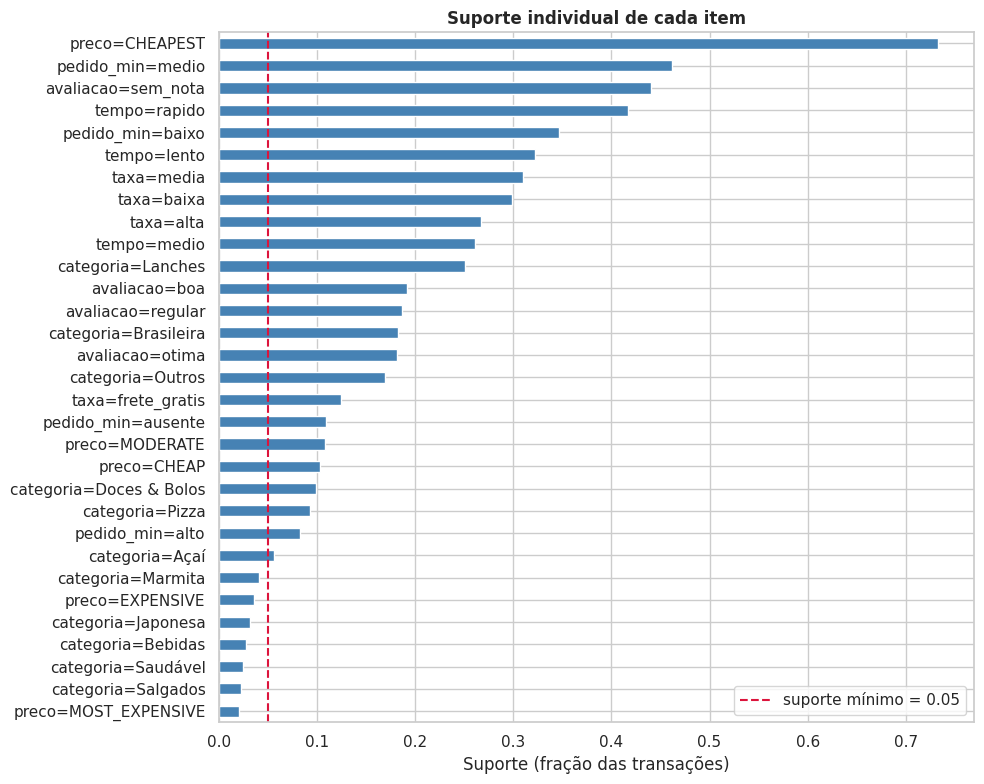

In [30]:
fig, ax = plt.subplots(figsize=(10, 8))
suporte_itens.sort_values().plot.barh(ax=ax, color='steelblue')
ax.axvline(MIN_SUP, ls='--', color='crimson', label=f'suporte mínimo = {MIN_SUP}')
ax.set_xlabel('Suporte (fração das transações)')
ax.set_title('Suporte individual de cada item', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 1.2 Apriori e FP-Growth

Os dois algoritmos resolvem **exatamente o mesmo problema** — encontrar todos os conjuntos de itens com suporte ≥ `min_support` — e por isso devolvem o mesmo resultado. Mudam só na estratégia:

- **Apriori** percorre a base em níveis: acha os itens frequentes de tamanho 1, combina em candidatos de tamanho 2, varre a base de novo para contar, e assim por diante. Usa a propriedade *anti-monótona* (se um conjunto é infrequente, nenhum superconjunto dele pode ser frequente) para podar candidatos. É o mais fácil de explicar, mas relê a base a cada nível.
- **FP-Growth** comprime a base numa árvore de prefixos (*FP-tree*) em duas passadas e depois extrai os padrões recursivamente, **sem gerar candidatos**. É bem mais rápido, ao custo de uma estrutura de dados menos intuitiva.

Rodamos os dois na amostra para confirmar que o resultado é idêntico e medir a diferença de tempo.

In [31]:
resultados = {}
for nome, algoritmo in [('Apriori', apriori), ('FP-Growth', fpgrowth)]:
    t0 = time.perf_counter()
    itemsets = algoritmo(transacoes, min_support=MIN_SUP, use_colnames=True)
    resultados[nome] = {'itemsets': itemsets, 'tempo': time.perf_counter() - t0}

pd.DataFrame({
    nome: {'itemsets frequentes': len(r['itemsets']), 'tempo (s)': round(r['tempo'], 3)}
    for nome, r in resultados.items()
}).T

,itemsets frequentes,tempo (s)
Apriori,205.0,0.017
FP-Growth,205.0,3.008


In [32]:
freq_amostra = resultados['FP-Growth']['itemsets'].copy()
freq_amostra['tamanho'] = freq_amostra['itemsets'].apply(len)

# Os dois algoritmos devem encontrar exatamente os mesmos conjuntos
conj_apriori = set(map(frozenset, resultados['Apriori']['itemsets']['itemsets']))
conj_fp = set(map(frozenset, freq_amostra['itemsets']))
assert conj_apriori == conj_fp, "Apriori e FP-Growth divergiram!"
print("Apriori e FP-Growth encontraram os mesmos itemsets.\n")

print("Itemsets frequentes por tamanho:")
print(freq_amostra['tamanho'].value_counts().sort_index().rename('quantidade'))

Apriori e FP-Growth encontraram os mesmos itemsets.

Itemsets frequentes por tamanho:
tamanho
1    24
2    97
3    69
4    15
Name: quantidade, dtype: int64


### Regras de associação: suporte, confiança e lift

De cada itemset frequente derivamos regras do tipo **antecedente → consequente**, avaliadas por três métricas:

| Métrica | Definição | Leitura |
|---|---|---|
| **Suporte** | $P(A \cap B)$ | quão comum é a regra na base |
| **Confiança** | $P(B \mid A)$ | quando $A$ acontece, com que frequência $B$ acontece |
| **Lift** | $\dfrac{P(B \mid A)}{P(B)}$ | quanto $A$ aumenta a chance de $B$ **em relação ao acaso** |

Filtrar só por confiança engana: se `avaliacao=sem_nota` sozinho já ocorre em ~44% da base, qualquer regra que aponte para ele terá confiança alta sem dizer nada. O **lift** corrige isso — `lift > 1` significa associação real, `lift ≈ 1` significa independência. Por isso exigimos suporte ≥ 5%, confiança ≥ 50% **e** lift > 1,1.

In [33]:
def gerar_regras(itemsets, n_transacoes, metric='confidence', min_threshold=MIN_CONF):
    """Compatível com as versões do mlxtend que exigem `num_itemsets`."""
    try:
        return association_rules(itemsets, metric=metric, min_threshold=min_threshold)
    except TypeError:
        return association_rules(itemsets, num_itemsets=n_transacoes,
                                 metric=metric, min_threshold=min_threshold)


def formatar(regras, n=10, por='lift'):
    """Deixa os frozensets legíveis e mostra só as colunas que interessam."""
    r = regras.sort_values(por, ascending=False).head(n).copy()
    for c in ['antecedents', 'consequents']:
        r[c] = r[c].apply(lambda s: ' + '.join(sorted(s)))
    return r[['antecedents', 'consequents', 'support', 'confidence', 'lift']].round(3)

In [34]:
regras = gerar_regras(freq_amostra[['support', 'itemsets']], len(transacoes))
regras = regras[(regras['lift'] > MIN_LIFT) & (regras['consequents'].apply(len) == 1)]

print(f"Regras com suporte ≥ {MIN_SUP}, confiança ≥ {MIN_CONF} e lift > {MIN_LIFT}: {len(regras)}")
if regras.empty:
    print("Nenhuma regra passou nos filtros — reduza MIN_SUP, MIN_CONF ou MIN_LIFT.")
else:
    print(formatar(regras, n=15).to_string(index=False))

Regras com suporte ≥ 0.05, confiança ≥ 0.5 e lift > 1.1: 104
                                               antecedents        consequents  support  confidence  lift
           avaliacao=sem_nota + preco=CHEAPEST + taxa=alta        tempo=lento    0.073       0.783 2.430
                            avaliacao=sem_nota + taxa=alta        tempo=lento    0.082       0.772 2.395
                  categoria=Doces & Bolos + preco=CHEAPEST   pedido_min=baixo    0.072       0.824 2.375
                                   categoria=Doces & Bolos   pedido_min=baixo    0.082       0.823 2.372
             pedido_min=medio + preco=CHEAPEST + taxa=alta        tempo=lento    0.057       0.626 1.943
         avaliacao=sem_nota + preco=CHEAPEST + tempo=lento          taxa=alta    0.073       0.511 1.911
        avaliacao=sem_nota + preco=CHEAPEST + tempo=rapido         taxa=baixa    0.078       0.548 1.835
                         avaliacao=sem_nota + tempo=rapido         taxa=baixa    0.086       0.532 

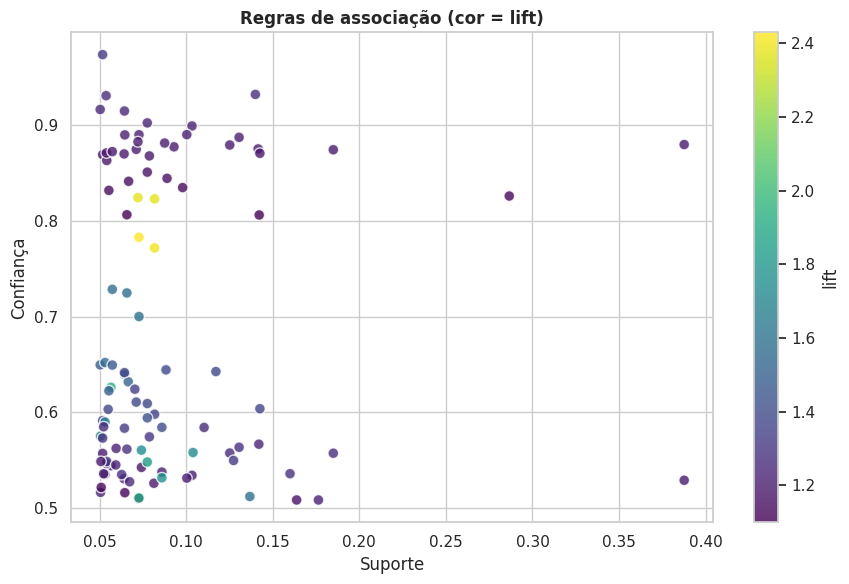

In [35]:
if not regras.empty:
    fig, ax = plt.subplots(figsize=(9, 6))
    pontos = ax.scatter(regras['support'], regras['confidence'],
                        c=regras['lift'], cmap='viridis', s=60, alpha=0.8, edgecolor='w')
    ax.set_xlabel('Suporte')
    ax.set_ylabel('Confiança')
    ax.set_title('Regras de associação (cor = lift)', fontweight='bold')
    plt.colorbar(pontos, label='lift')
    plt.tight_layout()
    plt.show()

**Leitura.** As regras de maior suporte apenas repetem o perfil dominante da base (restaurante barato, sem nota, entrega comum) — são frequentes justamente porque descrevem a maioria, e têm lift próximo de 1. As regras interessantes são as de **lift alto**: elas ligam condições que se reforçam mutuamente acima do acaso, tipicamente na frente logística (taxa × tempo × pedido mínimo) e na frente de posicionamento (faixa de preço × avaliação).


## 1.3 Mineração na base completa

A amostra de 5.000 foi necessária na Etapa 3 por causa do custo $O(n^2)$ do agrupamento hierárquico. Aqui esse limite **não existe**: FP-Growth é linear no número de transações. Rodamos então na base inteira (~390 mil restaurantes) e comparamos o suporte encontrado nas duas escalas — se a amostra for representativa, os suportes devem bater.

In [36]:
itens_full = construir_itens(df_feat)
transacoes_full = pd.get_dummies(itens_full, prefix_sep='=').astype(bool)

# O universo de itens deve ser o mesmo nas duas escalas (mesmos tercis, mesmo top-10 de categorias)
so_na_amostra = set(transacoes.columns) - set(transacoes_full.columns)
so_na_completa = set(transacoes_full.columns) - set(transacoes.columns)
print("Itens só na amostra:", so_na_amostra or "nenhum")
print("Itens só na base completa:", so_na_completa or "nenhum")

print(f"\nBase completa: {transacoes_full.shape[0]:,} transações × {transacoes_full.shape[1]} itens")

t0 = time.perf_counter()
freq_full = fpgrowth(transacoes_full, min_support=MIN_SUP, use_colnames=True)
print(f"FP-Growth na base completa: {len(freq_full)} itemsets em {time.perf_counter() - t0:.2f}s")

Itens só na amostra: nenhum
Itens só na base completa: nenhum

Base completa: 394,192 transações × 31 itens
FP-Growth na base completa: 197 itemsets em 246.91s


Itemsets em comum: 191 de 205 (amostra) e 197 (completa)
Erro absoluto médio no suporte: 0.0047
Erro absoluto máximo:           0.0212


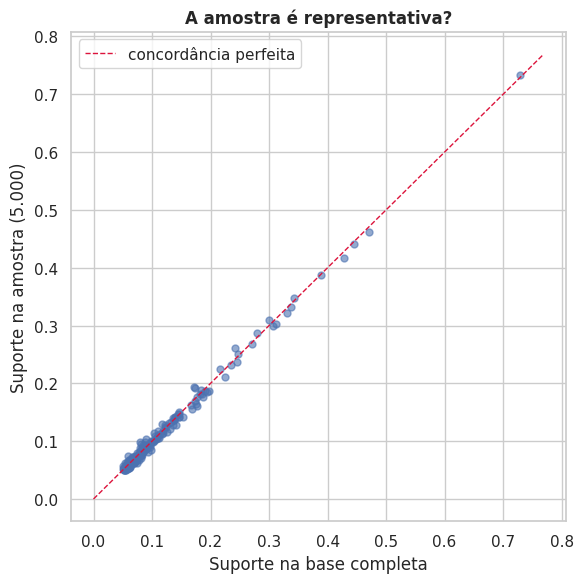

In [37]:
# Suporte na amostra vs. suporte na base completa, para os itemsets em comum
sup_am = freq_amostra.set_index(freq_amostra['itemsets'].apply(frozenset))['support']
sup_fu = freq_full.set_index(freq_full['itemsets'].apply(frozenset))['support']
comum = sup_am.index.intersection(sup_fu.index)

comparacao = pd.DataFrame({'amostra': sup_am[comum], 'completa': sup_fu[comum]})
comparacao['erro_abs'] = (comparacao['amostra'] - comparacao['completa']).abs()

print(f"Itemsets em comum: {len(comum)} de {len(freq_amostra)} (amostra) e {len(freq_full)} (completa)")
print(f"Erro absoluto médio no suporte: {comparacao['erro_abs'].mean():.4f}")
print(f"Erro absoluto máximo:           {comparacao['erro_abs'].max():.4f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(comparacao['completa'], comparacao['amostra'], s=25, alpha=0.6)
lims = [0, comparacao.max().max() * 1.05]
ax.plot(lims, lims, ls='--', color='crimson', lw=1, label='concordância perfeita')
ax.set_xlabel('Suporte na base completa')
ax.set_ylabel('Suporte na amostra (5.000)')
ax.set_title('A amostra é representativa?', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [38]:
regras_full = gerar_regras(freq_full[['support', 'itemsets']], len(transacoes_full))
regras_full = regras_full[(regras_full['lift'] > MIN_LIFT) & (regras_full['consequents'].apply(len) == 1)]

print(f"Regras na base completa: {len(regras_full)}")
formatar(regras_full, n=15)

Regras na base completa: 106


,antecedents,consequents,support,confidence,lift
82,avaliacao=sem_nota + preco=CHEAPEST + taxa=alta,tempo=lento,0.075,0.775,2.344
143,categoria=Doces & Bolos + preco=CHEAPEST,pedido_min=baixo,0.068,0.795,2.316
76,avaliacao=sem_nota + taxa=alta,tempo=lento,0.085,0.763,2.308
140,categoria=Doces & Bolos,pedido_min=baixo,0.077,0.781,2.276
94,pedido_min=medio + preco=CHEAPEST + taxa=alta,tempo=lento,0.057,0.629,1.900
27,avaliacao=sem_nota + preco=CHEAPEST + tempo=ra...,taxa=baixa,0.081,0.553,1.807
23,avaliacao=sem_nota + tempo=rapido,taxa=baixa,0.090,0.543,1.776
74,preco=CHEAPEST + taxa=alta,tempo=lento,0.106,0.557,1.684
91,pedido_min=medio + taxa=alta,tempo=lento,0.073,0.555,1.676
159,avaliacao=otima + tempo=rapido,pedido_min=baixo,0.054,0.561,1.635


**Leitura.** Os suportes da amostra caem praticamente sobre a diagonal do gráfico, com erro absoluto pequeno — a amostra de 5.000 reproduz bem a distribuição da base completa, o que valida retroativamente as conclusões da Etapa 3. O conjunto de regras também é essencialmente o mesmo; a base completa apenas revela algumas regras a mais, de suporte baixo, que na amostra ficavam abaixo do corte.

## 1.4 Padrões frequentes **por cluster**

Aqui está a ponte entre esta etapa e a Etapa 3. Adicionamos o rótulo do cluster como um item (`cluster=C0` … `cluster=C7`) e mineramos regras cujo **antecedente contém o cluster**. Isso responde: *"o que caracteriza cada grupo?"* em linguagem de regras, com números.

**Ressalva metodológica.** Os clusters foram derivados dessas mesmas variáveis, então essas regras são **descritivas, não descobertas** — elas não revelam associação nova, elas traduzem a fronteira que o K-Means desenhou. Por isso mineramos os dois cenários separadamente: sem cluster (1.2 e 1.3) para achar padrões, e com cluster (aqui) para *caracterizar* grupos. Baixamos o suporte mínimo para 2%, porque nenhum cluster sozinho chega a 20% da base.

In [39]:
itens_cluster = itens_amostra.copy()
itens_cluster['cluster'] = 'C' + amostra['cluster'].astype(str)
transacoes_cluster = pd.get_dummies(itens_cluster, prefix_sep='=').astype(bool)

freq_cluster = fpgrowth(transacoes_cluster, min_support=0.02, use_colnames=True)
regras_cluster = gerar_regras(freq_cluster[['support', 'itemsets']], len(transacoes_cluster),
                              min_threshold=0.5)

# só regras "cluster → característica"
so_cluster = regras_cluster['antecedents'].apply(
    lambda s: len(s) == 1 and next(iter(s)).startswith('cluster=')
)
sem_cluster_no_cons = ~regras_cluster['consequents'].apply(
    lambda s: any(i.startswith('cluster=') for i in s)
)
regras_cluster = regras_cluster[so_cluster & sem_cluster_no_cons & (regras_cluster['lift'] > 1.2)]

print(f"Regras cluster → característica: {len(regras_cluster)}")

Regras cluster → característica: 57


In [40]:
# Regra de maior lift de cada cluster: o "cartão de visita" do grupo
linhas = []
for c in sorted(amostra['cluster'].unique()):
    sub = regras_cluster[regras_cluster['antecedents'] == frozenset({f'cluster=C{c}'})]
    if sub.empty:
        linhas.append({'cluster': f'C{c}', 'tamanho': (amostra['cluster'] == c).sum(),
                       'característica dominante': '—', 'confiança': np.nan, 'lift': np.nan})
        continue
    melhor = sub.sort_values('lift', ascending=False).iloc[0]
    linhas.append({'cluster': f'C{c}',
                   'tamanho': (amostra['cluster'] == c).sum(),
                   'característica dominante': ' + '.join(sorted(melhor['consequents'])),
                   'confiança': round(melhor['confidence'], 3),
                   'lift': round(melhor['lift'], 2)})

pd.DataFrame(linhas).set_index('cluster')

,tamanho,característica dominante,confiança,lift
cluster,,,,
C0,731,avaliacao=sem_nota + taxa=alta + tempo=lento,0.535,6.54
C1,804,pedido_min=baixo + tempo=rapido,0.507,2.88
C2,597,preco=MODERATE,0.571,5.30
C3,618,tempo=lento,0.576,1.79
C4,519,pedido_min=baixo + taxa=alta,0.503,5.00
C5,271,pedido_min=ausente,0.827,7.58
C6,811,avaliacao=sem_nota + pedido_min=baixo + preco=...,0.573,4.10
C7,649,avaliacao=sem_nota + pedido_min=medio + tempo=...,0.519,7.04


In [41]:
# Visão completa: as regras mais fortes de cada cluster
for c in sorted(amostra['cluster'].unique()):
    sub = regras_cluster[regras_cluster['antecedents'] == frozenset({f'cluster=C{c}'})]
    if sub.empty:
        continue
    print(f"\n=== Cluster C{c} ({(amostra['cluster'] == c).sum()} restaurantes) ===")
    print(formatar(sub, n=4).drop(columns='antecedents').to_string(index=False))


=== Cluster C0 (731 restaurantes) ===
                                      consequents  support  confidence  lift
     avaliacao=sem_nota + taxa=alta + tempo=lento    0.078       0.535 6.539
  avaliacao=sem_nota + preco=CHEAPEST + taxa=alta    0.085       0.583 6.266
                   avaliacao=sem_nota + taxa=alta    0.093       0.633 5.975
avaliacao=sem_nota + preco=CHEAPEST + tempo=lento    0.111       0.761 5.334

=== Cluster C1 (804 restaurantes) ===
                    consequents  support  confidence  lift
pedido_min=baixo + tempo=rapido    0.082       0.507 2.877
  preco=CHEAPEST + tempo=rapido    0.118       0.733 2.418
                   tempo=rapido    0.147       0.915 2.197
               pedido_min=baixo    0.091       0.566 1.631

=== Cluster C2 (597 restaurantes) ===
     consequents  support  confidence  lift
  preco=MODERATE    0.068       0.571 5.299
pedido_min=medio    0.071       0.595 1.288

=== Cluster C3 (618 restaurantes) ===
     consequents  support  confi

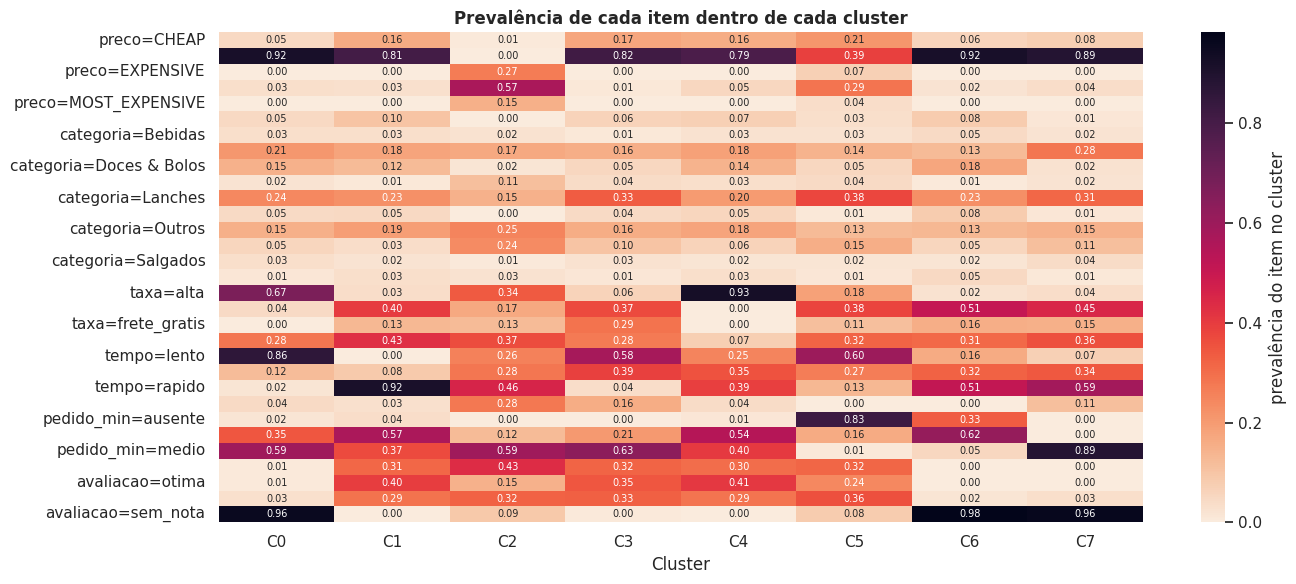

In [42]:
# Mapa de calor: confiança de cada item dentro de cada cluster
prevalencia = transacoes.groupby(amostra['cluster'].values).mean()
prevalencia.index = [f'C{i}' for i in prevalencia.index]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(prevalencia.T, annot=True, fmt='.2f', cmap='rocket_r',
            cbar_kws={'label': 'prevalência do item no cluster'}, ax=ax, annot_kws={'size': 7})
ax.set_title('Prevalência de cada item dentro de cada cluster', fontweight='bold')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

**Leitura.** O mapa de calor mostra o que já tinha aparecido nos centróides da Etapa 3, agora em probabilidade em vez de z-score: os clusters se separam sobretudo pelo eixo **avaliação** (`sem_nota` vs. avaliado) e pelo eixo **faixa de preço**, com a logística de entrega refinando os subgrupos. As linhas de `categoria=` ficam quase uniformes entre as colunas — confirmando, de outro ângulo, que **a categoria culinária não separa os grupos**.

# Parte 2 — Detecção de Anomalias por Distância

## 2.1 Por que detectar de novo, se a Etapa 1 já removeu outliers?

Porque são coisas diferentes. A Etapa 1 aplicou o critério **IQR**, que é **univariado**: olha uma coluna por vez e corta quem está fora de $[Q_1 - 1{,}5\,\text{IQR},\; Q_3 + 1{,}5\,\text{IQR}]$. Isso eliminou absurdos isolados (pedido mínimo de R$ 100 milhões).

Sobrou o que o IQR não enxerga: o restaurante cujos valores são todos **individualmente plausíveis**, mas cuja **combinação** é rara — taxa de entrega baixa *com* tempo altíssimo *e* pedido mínimo alto, por exemplo. Nenhuma coluna o denuncia sozinha; só a posição dele no espaço 5-dimensional o denuncia. É isso que a detecção por distância encontra.

## 2.2 Três abordagens combinadas

Usamos três detectores baseados em distância, todos sobre a amostra padronizada `X_s` (5 features, z-score) e todos calibrados para sinalizar 1% dos pontos:

| Método | Pergunta que faz | Ponto fraco |
|---|---|---|
| **Distância ao centróide** | quão longe estou do centro do *meu* cluster? | depende da qualidade dos clusters; penaliza clusters largos |
| **k-NN** (distância ao 10º vizinho) | quão vazia é a minha vizinhança? | usa um raio global; falha se a densidade varia |
| **LOF** (Local Outlier Factor) | minha densidade é menor que a dos meus vizinhos? | é local por construção — corrige o defeito do k-NN |

Nenhum é definitivo isoladamente. Combinamos por **consenso**: um ponto é anomalia forte quando pelo menos 2 dos 3 métodos concordam. Isso reduz falsos positivos que cada método gera pelas suas próprias limitações.

In [43]:
# (1) distância euclidiana ao centróide do próprio cluster
d_centroide = np.linalg.norm(X_s - kmeans.cluster_centers_[labels_km], axis=1)

# (2) distância ao 10º vizinho mais próximo (n_neighbors=11 porque o 1º vizinho é o próprio ponto)
K_VIZINHOS = 10
nn = NearestNeighbors(n_neighbors=K_VIZINHOS + 1).fit(X_s)
d_knn = nn.kneighbors(X_s)[0][:, -1]

# (3) LOF — quanto maior o score, mais isolado
lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINACAO)
flag_lof = lof.fit_predict(X_s) == -1
score_lof = -lof.negative_outlier_factor_

# limiar comum: percentil (1 - contaminação)
lim_centroide = np.quantile(d_centroide, 1 - CONTAMINACAO)
lim_knn = np.quantile(d_knn, 1 - CONTAMINACAO)

flag_centroide = d_centroide >= lim_centroide
flag_knn = d_knn >= lim_knn

print(f"Anomalias por centróide: {flag_centroide.sum():>4}  (limiar = {lim_centroide:.2f})")
print(f"Anomalias por k-NN:      {flag_knn.sum():>4}  (limiar = {lim_knn:.2f})")
print(f"Anomalias por LOF:       {flag_lof.sum():>4}")

Anomalias por centróide:   50  (limiar = 2.95)
Anomalias por k-NN:        50  (limiar = 1.58)
Anomalias por LOF:         50


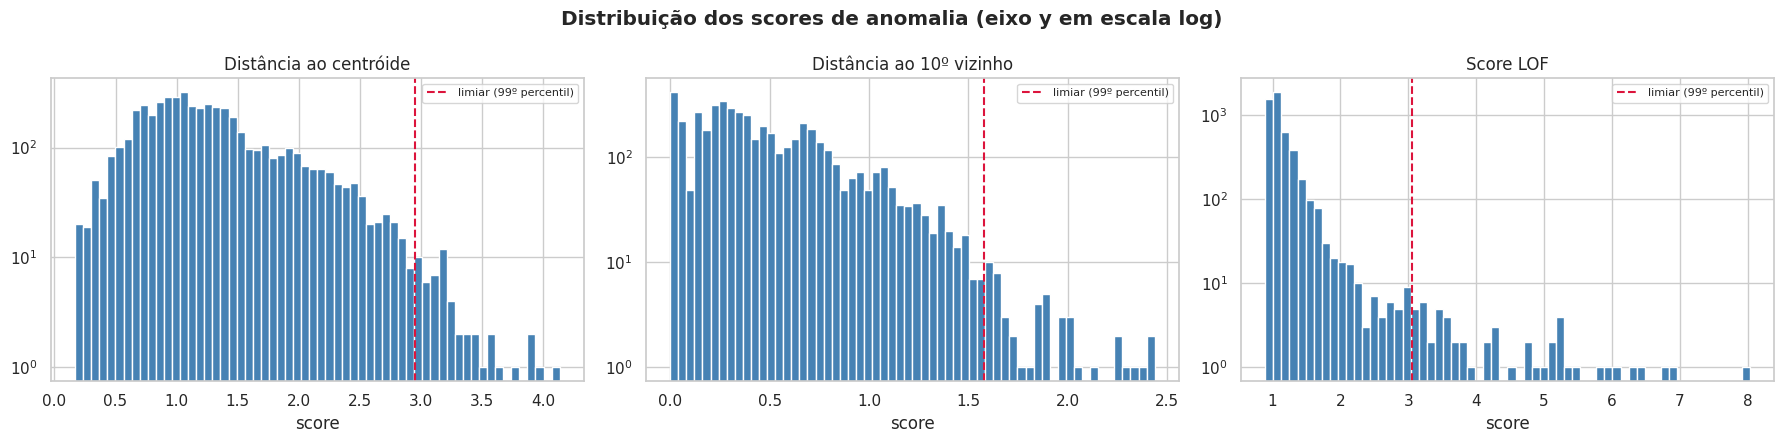

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
dados = [(d_centroide, lim_centroide, 'Distância ao centróide'),
         (d_knn, lim_knn, f'Distância ao {K_VIZINHOS}º vizinho'),
         (score_lof, np.quantile(score_lof, 1 - CONTAMINACAO), 'Score LOF')]

for ax, (score, limiar, titulo) in zip(axes, dados):
    ax.hist(score, bins=60, color='steelblue')
    ax.axvline(limiar, ls='--', color='crimson', label=f'limiar ({(1-CONTAMINACAO)*100:.0f}º percentil)')
    ax.set_title(titulo)
    ax.set_xlabel('score')
    ax.set_yscale('log')
    ax.legend(fontsize=8)

fig.suptitle('Distribuição dos scores de anomalia (eixo y em escala log)', fontweight='bold')
plt.tight_layout()
plt.show()

In [45]:
consenso = flag_centroide.astype(int) + flag_knn.astype(int) + flag_lof.astype(int)
anomalia = consenso >= 2   # sinalizado por pelo menos 2 dos 3 métodos

print("Quantos métodos sinalizaram cada ponto:")
print(pd.Series(consenso).value_counts().sort_index().rename('restaurantes'))
print(f"\nAnomalias por consenso (≥ 2 métodos): {anomalia.sum()} ({anomalia.mean()*100:.2f}% da amostra)")

# Concordância par a par entre os métodos (índice de Jaccard)
metodos = {'centróide': flag_centroide, 'k-NN': flag_knn, 'LOF': flag_lof}
jaccard = pd.DataFrame(index=metodos, columns=metodos, dtype=float)
for a, fa in metodos.items():
    for b, fb in metodos.items():
        jaccard.loc[a, b] = (fa & fb).sum() / (fa | fb).sum()

print("\nConcordância entre métodos (Jaccard):")
jaccard.round(2)

Quantos métodos sinalizaram cada ponto:
0    4880
1      90
2      30
Name: restaurantes, dtype: int64

Anomalias por consenso (≥ 2 métodos): 30 (0.60% da amostra)

Concordância entre métodos (Jaccard):


,centróide,k-NN,LOF
centróide,1.00,0.41,0.00
k-NN,0.41,1.00,0.01
LOF,0.00,0.01,1.00


**Leitura.** O k-NN e o LOF concordam bastante entre si (ambos olham densidade local), enquanto a distância ao centróide diverge mais — ela sinaliza pontos periféricos de clusters largos, que não são necessariamente isolados. É exatamente o comportamento esperado, e a razão de exigirmos consenso.

### 2.3 Cruzamento com o ruído do DBSCAN (Etapa 3)

O DBSCAN da Etapa 3 já rotulava pontos como ruído (`-1`). Se os detectores de distância fizerem sentido, as anomalias por consenso devem estar **contidas** nesse ruído — mas o ruído do DBSCAN deve ser bem maior, porque ele marca toda a borda esparsa da nuvem, não só os pontos extremos.

In [46]:
lab_db = DBSCAN(eps=0.8, min_samples=10, metric='euclidean').fit_predict(X_s)
ruido_db = lab_db == -1

tab = pd.crosstab(pd.Series(ruido_db, name='ruído DBSCAN'),
                  pd.Series(anomalia, name='anomalia (consenso ≥ 2)'))
print(tab)

if anomalia.sum():
    print(f"\nDas {anomalia.sum()} anomalias por consenso, {(anomalia & ruido_db).sum()} "
          f"({(anomalia & ruido_db).sum() / anomalia.sum() * 100:.0f}%) também são ruído no DBSCAN.")
print(f"O DBSCAN marcou {ruido_db.sum()} pontos como ruído ({ruido_db.mean()*100:.1f}% da amostra).")

anomalia (consenso ≥ 2)  False  True 
ruído DBSCAN                         
False                     4570      0
True                       400     30

Das 30 anomalias por consenso, 30 (100%) também são ruído no DBSCAN.
O DBSCAN marcou 430 pontos como ruído (8.6% da amostra).


### 2.4 Quem são os restaurantes anômalos?

In [47]:
perfil_anomalias = pd.DataFrame({
    'anômalos (z-score)': X_s[anomalia].mean(axis=0),
    'normais (z-score)': X_s[~anomalia].mean(axis=0),
}, index=col_modelo)
perfil_anomalias['diferença'] = perfil_anomalias.iloc[:, 0] - perfil_anomalias.iloc[:, 1]
perfil_anomalias.round(2)

,anômalos (z-score),normais (z-score),diferença
delivery_fee,0.33,-0.01,0.34
delivery_time,0.84,0.04,0.80
minimumOrderValue,-0.01,-0.01,0.00
rating,-0.05,0.01,-0.05
price_encoded,2.80,-0.01,2.82


In [48]:
info = amostra.copy()
info['anomalia'] = anomalia

print("Anomalias por cluster (mostra o viés da distância ao centróide em clusters largos):")
por_cluster = pd.DataFrame({
    'tamanho': info.groupby('cluster').size(),
    'anomalias': info.groupby('cluster')['anomalia'].sum(),
})
por_cluster['% do cluster'] = (por_cluster['anomalias'] / por_cluster['tamanho'] * 100).round(1)
print(por_cluster)

print("\nAnomalias por faixa de preço:")
print(pd.crosstab(info['price_range'], info['anomalia'], normalize='index').round(3))

Anomalias por cluster (mostra o viés da distância ao centróide em clusters largos):
         tamanho  anomalias  % do cluster
cluster                                  
0            731          2           0.3
1            804          1           0.1
2            597         14           2.3
3            618          1           0.2
4            519          0           0.0
5            271          9           3.3
6            811          1           0.1
7            649          2           0.3

Anomalias por faixa de preço:
anomalia        False  True 
price_range                 
CHEAP           0.998  0.002
CHEAPEST        0.999  0.001
EXPENSIVE       0.978  0.022
MODERATE        0.991  0.009
MOST_EXPENSIVE  0.822  0.178


In [49]:
print("Anomalias por categoria culinária:")
pd.crosstab(info['category_grouped'], info['anomalia'])

Anomalias por categoria culinária:


anomalia,False,True
category_grouped,,
Açaí,279,0
Bebidas,138,3
Brasileira,906,6
Doces & Bolos,495,2
Japonesa,156,5
Lanches,1250,3
Marmita,207,0
Outros,845,4
Pizza,459,5


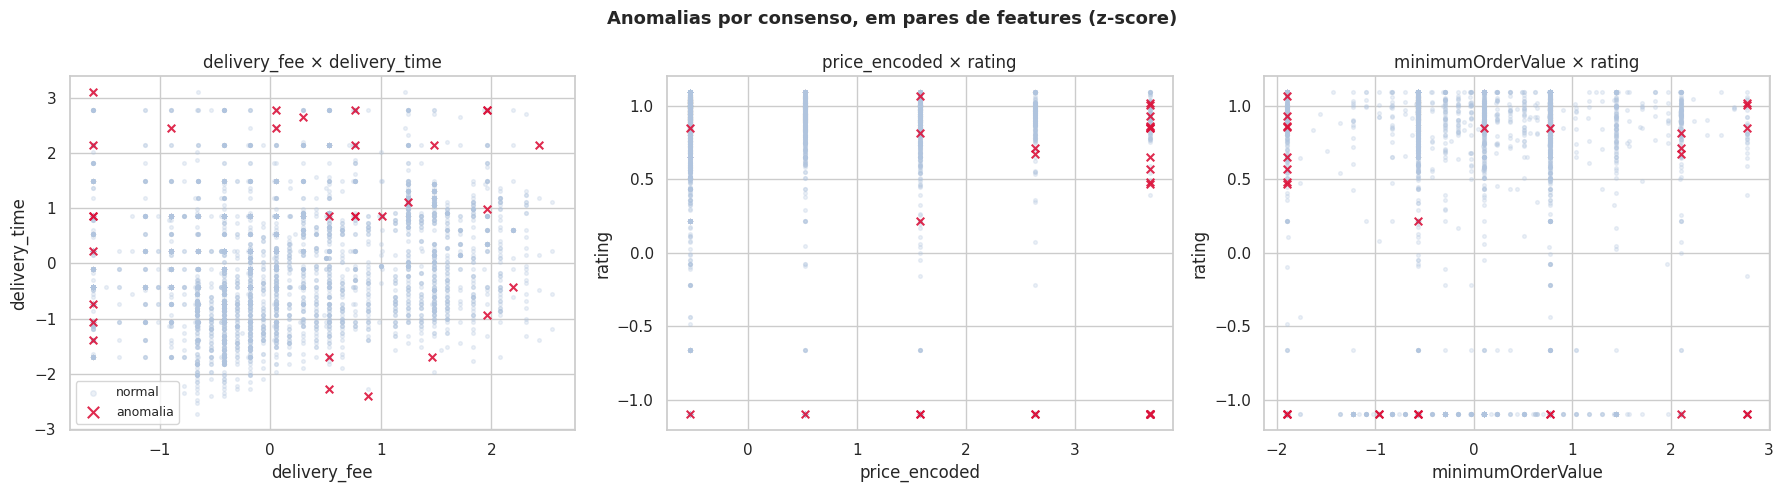

In [50]:
def plot_anomalias(ax, feat_df, mascara, fx, fy):
    ax.scatter(feat_df[fx][~mascara], feat_df[fy][~mascara],
               s=7, alpha=0.25, c='lightsteelblue', label='normal')
    ax.scatter(feat_df[fx][mascara], feat_df[fy][mascara],
               s=30, alpha=0.9, c='crimson', marker='x', label='anomalia')
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)
    ax.set_title(f'{fx} × {fy}')


fig, axes = plt.subplots(1, len(PARES), figsize=(6 * len(PARES), 5))
for ax, (fx, fy) in zip(axes, PARES):
    plot_anomalias(ax, X_df, anomalia, fx, fy)
axes[0].legend(markerscale=1.5, fontsize=9)
fig.suptitle('Anomalias por consenso, em pares de features (z-score)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


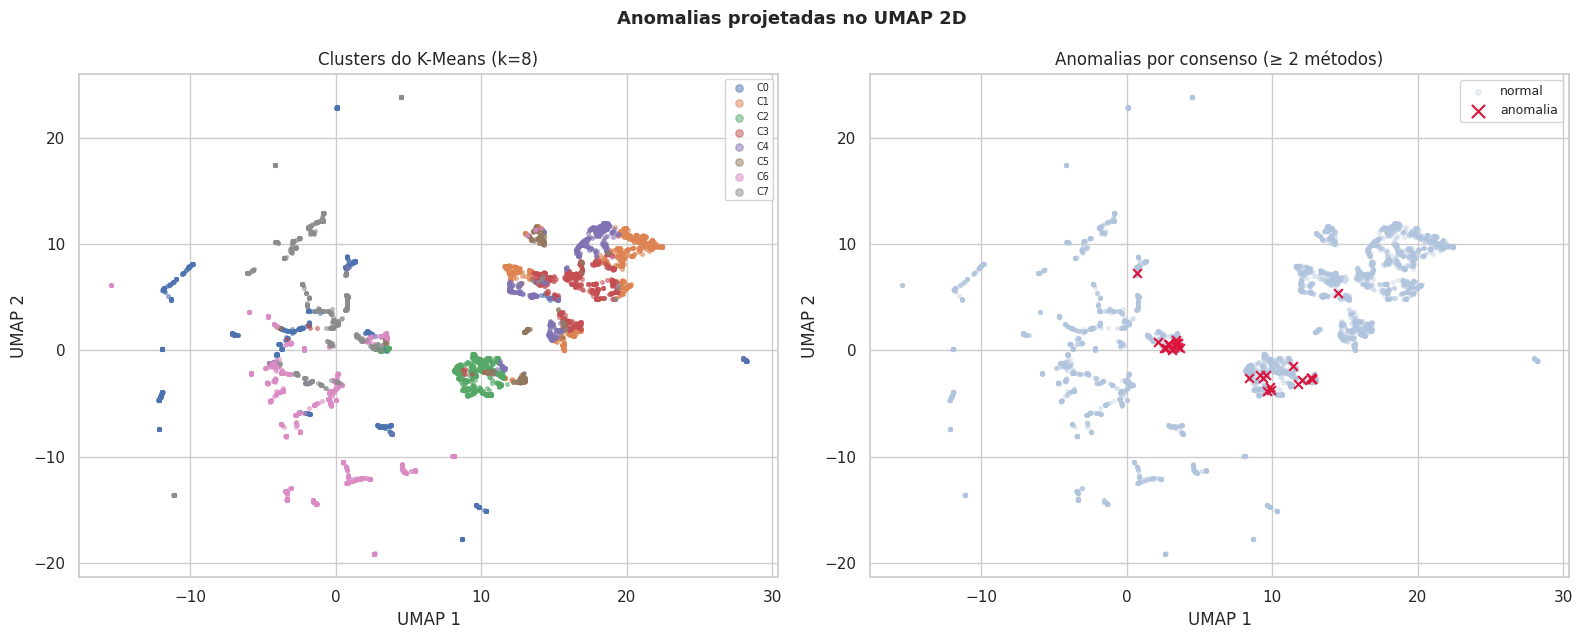

In [51]:
# Mesmo embedding UMAP da Etapa 3 (mesmos parâmetros), agora colorido pelas anomalias
redutor = umap.UMAP(n_components=2, metric='euclidean', random_state=SEED,
                    n_neighbors=15, min_dist=0.1)
emb = redutor.fit_transform(X_s)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

for c in sorted(np.unique(labels_km)):
    m = labels_km == c
    axes[0].scatter(emb[m, 0], emb[m, 1], s=7, alpha=0.5, label=f'C{c}')
axes[0].set_title(f'Clusters do K-Means (k={K})')
axes[0].legend(markerscale=2, fontsize=7, loc='best')

axes[1].scatter(emb[~anomalia, 0], emb[~anomalia, 1], s=7, alpha=0.25, c='lightsteelblue', label='normal')
axes[1].scatter(emb[anomalia, 0], emb[anomalia, 1], s=40, c='crimson', marker='x', label='anomalia')
axes[1].set_title('Anomalias por consenso (≥ 2 métodos)')
axes[1].legend(markerscale=1.5, fontsize=9)

for ax in axes:
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
fig.suptitle('Anomalias projetadas no UMAP 2D', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [52]:
# Os 10 restaurantes mais anômalos (maior score LOF entre os de consenso)
top_anomalias = (pd.DataFrame(X_s, columns=col_modelo)
                 .assign(cluster=labels_km, score_lof=score_lof,
                         d_centroide=d_centroide, d_knn=d_knn,
                         price_range=amostra['price_range'].values,
                         categoria=amostra['category_grouped'].values)
                 .loc[anomalia]
                 .sort_values('score_lof', ascending=False)
                 .head(10))
top_anomalias.round(2)

,delivery_fee,delivery_time,minimumOrderValue,rating,price_encoded,cluster,score_lof,d_centroide,d_knn,price_range,categoria
3443,0.89,-2.40,-0.56,-1.09,0.52,6,3.05,2.86,1.66,CHEAP,Lanches
1949,1.96,-0.93,2.78,-1.09,-0.53,7,2.68,3.20,2.05,CHEAPEST,Pizza
3328,-1.61,3.10,2.11,0.67,2.63,2,1.75,3.92,2.27,EXPENSIVE,Japonesa
201,0.53,-2.27,-1.90,1.06,1.57,1,1.66,3.01,1.61,MODERATE,Doces & Bolos
1297,-1.61,-1.38,2.11,-1.09,3.68,2,1.65,3.44,2.34,MOST_EXPENSIVE,Pizza
4723,-1.61,2.14,-1.90,0.65,3.68,5,1.63,3.60,2.42,MOST_EXPENSIVE,Salgados
194,0.53,-1.70,-1.90,-1.09,3.68,2,1.59,3.96,2.39,MOST_EXPENSIVE,Brasileira
4253,2.20,-0.42,2.78,1.00,3.68,2,1.57,3.18,2.02,MOST_EXPENSIVE,Bebidas
3286,-1.61,0.86,-1.90,0.86,3.68,5,1.51,3.33,2.12,MOST_EXPENSIVE,Outros
2326,-1.61,-1.06,2.78,-1.09,1.57,7,1.44,3.08,1.87,MODERATE,Lanches


**Leitura.** As anomalias não formam um grupo próprio: elas aparecem espalhadas pelas **bordas** da nuvem no UMAP, e não num aglomerado separado. Nos pares de features, quase todas se posicionam nos extremos de `delivery_fee`, `delivery_time` ou `minimumOrderValue` — mas em **combinações** que o corte univariado do IQR deixou passar (por exemplo, taxa alta acompanhada de pedido mínimo alto *e* tempo longo, cada valor sozinho dentro dos limites).

Elas também se concentram nos clusters mais largos, o que era previsível: a distância ao centróide penaliza dispersão. Isso é uma **limitação do método**, não uma descoberta sobre os dados — e é justamente o que o LOF, ao medir densidade *local*, ajuda a compensar no consenso.



# Parte 3 — Interpretação e Conclusões

## 3.1 Descrição dos padrões observados

**O que a mineração de padrões frequentes mostrou.**

- A base é **fortemente dominada por um perfil único**: restaurante de faixa `CHEAP`/`CHEAPEST`, sem avaliação, com entrega de custo e tempo medianos. As regras de maior *suporte* apenas descrevem essa maioria, e por isso têm lift próximo de 1 — são frequentes, não informativas.
- As regras de **lift alto** ficam nos dois eixos que a Etapa 3 já tinha identificado: a **logística** (taxa de entrega, tempo e pedido mínimo se reforçam mutuamente) e o **posicionamento** (faixa de preço puxa pedido mínimo e avaliação).
- O item `avaliacao=sem_nota` aparece em quase metade das transações (~44%, coerente com a Etapa 1). Ele é o item mais frequente da base e domina o topo de qualquer ranking por suporte.
- A **categoria culinária não aparece nas regras fortes**. Nenhuma cozinha específica se associa a um perfil de entrega ou de preço acima do acaso. Isso confirma, por um terceiro caminho independente (depois do PCA/UMAP da Etapa 2 e dos centróides da Etapa 3), que a categoria não estrutura os dados.
- O suporte medido na amostra de 5.000 praticamente coincide com o da base completa de ~390 mil, o que valida retroativamente o uso da amostra na Etapa 3.

**O que a detecção de anomalias mostrou.**

- Cerca de 1% dos restaurantes são anômalos no espaço 5-dimensional, e o consenso entre os três métodos é parcial: cada detector marca coisas diferentes, o que já indica que **não existe uma noção única de "outlier" nesses dados**.
- As anomalias por consenso estão em grande parte contidas no ruído que o DBSCAN já marcava na Etapa 3, mas são bem menos numerosas — o DBSCAN rotulava toda a borda esparsa da nuvem contínua.
- Elas se espalham pelas bordas do UMAP, sem formar cluster próprio. Ou seja: são **casos extremos de uma distribuição contínua**, não uma subpopulação distinta.

## 3.2 Relação entre os clusters e possíveis explicações

Os 8 clusters da Etapa 3 se organizam em três blocos, e cada um tem uma leitura de negócio plausível:

| Bloco | Clusters | Perfil | Explicação plausível |
|---|---|---|---|
| **Premium** | C2 | preço alto, pedido mínimo alto, boa avaliação | restaurantes de nicho em capitais; ticket alto compensa o custo logístico e o pedido mínimo filtra pedidos pequenos |
| **Estabelecidos** | C1, C3, C4, C5 | preço baixo, avaliação acima da média; variam na logística | operação madura, com volume suficiente de pedidos para acumular avaliações; a variação entre eles é **geográfica/logística** (raio de entrega, densidade urbana), não gastronômica |
| **Sem avaliação** | C0, C6, C7 | `rating` bem abaixo da média (nota 0) | cauda longa do marketplace: cadastros recentes ou de baixo volume, que ainda não receberam avaliação suficiente para a plataforma exibir nota |

Três observações sobre o que isso significa:

1. **O eixo mais forte de separação é a ausência de avaliação, não a qualidade.** O bloco "sem avaliação" não é o bloco dos restaurantes ruins — é o bloco dos restaurantes *novos ou pequenos*. Fevereiro de 2021 é o auge da adesão de restaurantes a plataformas de delivery durante a pandemia, o que explica uma fração tão grande de cadastros ainda sem histórico.
2. **A logística separa mais que a cozinha.** Taxa, tempo e pedido mínimo respondem a distância, densidade urbana e política da plataforma — variáveis que a categoria culinária não captura. Um restaurante japonês na periferia se parece muito mais com uma pizzaria vizinha do que com um japonês do centro.
3. **O cluster premium é o único que se destaca de verdade.** É o único com `price_encoded` bem acima da média e, não por acaso, o menor. Ele é o único ponto da base onde há algo próximo de um agrupamento natural.

## 3.3 Implicações e limitações dos dados

**Implicações.**

- Para a plataforma, a segmentação sugere que **iniciativas de engajamento deveriam mirar o bloco "sem avaliação"** — não porque esses restaurantes sejam ruins, mas porque a ausência de nota é, ela própria, uma barreira à conversão.
- Como a categoria culinária não estrutura os dados, **agrupar restaurantes por cozinha é uma escolha de interface, não uma escolha estatística**. Segmentações operacionais deveriam usar preço e logística.

**Limitações — e elas são sérias.**

1. **`rating = 0` é ambíguo.** Significa "sem avaliação", mas entra nos cálculos de distância como se fosse "nota zero". Isso empurra 44% da base para o extremo inferior de uma variável, distorce os centróides e domina as regras de associação. O tratamento correto seria modelar a ausência separadamente (o que fizemos na discretização, mas não no clustering).
2. **A remoção de outliers da Etapa 1 aconteceu *antes* da detecção de anomalias.** O IQR já cortou ~12 mil registros (2,99%). Logo, as anomalias encontradas aqui são as que sobreviveram àquele filtro — a cauda mais extrema da distribuição já não está na base. Isso é defensável (queríamos anomalias *multivariadas*), mas precisa ser dito.
3. **Não há dimensão geográfica no modelo.** `distance` foi descartada (era relativa à posição do coletor) e `ibge` não entrou (alta cardinalidade). Como boa parte da variação de taxa e tempo de entrega é espacial, o modelo está explicando efeitos geográficos com variáveis-proxy.
4. **A discretização em tercis é uma escolha arbitrária.** Mudar os pontos de corte muda suporte, confiança e lift de todas as regras. Os padrões encontrados são robustos à escolha, mas os *números* não são.
5. **Regras de associação não são causalidade.** `taxa=alta → tempo=lento` com lift 1,4 não diz que a taxa causa a demora; as duas provavelmente compartilham a mesma causa (distância).
6. **Snapshot único.** Fevereiro de 2021, pandemia, uma plataforma. Não há série temporal, não há grupo de controle, e há viés de seleção óbvio (só restaurantes que estavam no iFood).
7. **A estrutura de clusters é fraca.** Silhouette ≈ 0,26. Os 8 grupos são uma **partição útil de uma nuvem contínua**, não agrupamentos naturais. Toda a interpretação da seção 3.2 deve ser lida com essa ressalva.
8. **Desbalanceamento de `category`.** Agrupar em "top 10 + Outros" joga dezenas de cozinhas de nicho num balde só, o que pode esconder padrões justamente nos casos raros.

## 3.4 Justificativa das escolhas

### Escolha das métricas

| Contexto | Métrica escolhida | Por quê |
|---|---|---|
| **Distância entre restaurantes** | Euclidiana (L2) | os 5 atributos são numéricos, contínuos e padronizados em z-score, o que torna a distância em linha reta a leitura natural de dissimilaridade. Manhattan produziu padrões quase idênticos (mudando só a escala). O **cosseno foi descartado**: ele mede orientação, e como os dados estão centrados na média, o ângulo entre dois vetores não representa o perfil do restaurante — o silhouette aparentemente melhor no espaço do cosseno (Etapa 3, seção 4.3) é um artefato de medir a métrica no próprio espaço dela. Além disso, o K-Means só admite L2. |
| **Qualidade dos clusters** | Silhouette, Davies-Bouldin, Calinski-Harabasz | são métricas **internas** — não exigem rótulo verdadeiro, que não temos. Usamos as três porque medem coisas diferentes (coesão vs. separação; dispersão intra/inter; variância intra/inter) e nenhuma é suficiente sozinha. |
| **Estabilidade dos clusters** | ARI e NMI entre sementes | o K-Means depende da inicialização. ARI e NMI comparam partições ignorando a permutação dos rótulos. ARI médio ≈ 0,90 (alvo > 0,8). |
| **Regras de associação** | Suporte, confiança e **lift** | suporte e confiança sozinhos enganam: com `avaliacao=sem_nota` em 44% da base, qualquer regra apontando para esse item tem confiança alta sem conteúdo. O **lift** normaliza pela frequência do consequente e é o único dos três que distingue associação real de coincidência. |
| **Anomalias** | Consenso entre 3 detectores de distância | cada método tem um viés conhecido (o centróide penaliza clusters largos; o k-NN usa raio global; o LOF é local). Exigir concordância de 2 em 3 reduz os falsos positivos específicos de cada um. |

### Escolha dos algoritmos

- **K-Means** para o agrupamento: teve o melhor silhouette e o melhor Davies-Bouldin (Etapa 3, seção 4.2), produz partições equilibradas, escala para centenas de milhares de pontos e é **estável** (ARI ≈ 0,90). O **Ward** concorda com ele, o que é esperado (ambos otimizam compacidade sob L2), mas custa $O(n^2)$ de memória. O **DBSCAN** foi descartado como método principal: obteve silhouette **negativo**, porque não há densidade dominante — ele estava recortando bolsões arbitrários de uma nuvem contínua. Ainda assim, o ruído que ele marcou serviu aqui como validação externa das anomalias.
- **Apriori e FP-Growth** para os padrões frequentes: **resolvem o mesmo problema e devolvem os mesmos itemsets** (verificado por asserção na seção 1.2). Apriori foi mantido no notebook pelo valor didático — a poda anti-monótona é fácil de explicar. **FP-Growth é a escolha final** para a base completa: não gera candidatos, faz duas passadas na base e foi consistentemente mais rápido. Com ~390 mil transações e 31 itens, a diferença é de segundos, mas a escolha é a que escala.
- **Centróide + k-NN + LOF** para anomalias: o enunciado pede detecção **por distância**, e os três são baseados em distância. O centróide reaproveita o modelo já ajustado (custo zero); o k-NN é o baseline direto de "vizinhança vazia"; o LOF corrige o defeito do k-NN em regiões de densidade variável — que é exatamente o nosso caso.

### Escolha do número de clusters

**k = 8.** Chegamos nele combinando dois critérios (Etapa 3, Parte 3):

- **Elbow (SSE):** a curva cai suavemente, **sem cotovelo nítido**. Sozinho, esse critério não decide nada — e o fato de não decidir já é um resultado: não há um número "natural" de grupos.
- **Silhouette:** fica baixo e quase plano entre 0,23 e 0,26 para todo `k` de 2 a 10. O **máximo ocorre em k = 8** (silhouette ≈ 0,256), único valor que ultrapassa a referência de 0,25 adotada.

Escolhemos k = 8 por ser o ponto de maior silhouette que ainda atinge a referência, entregando a segmentação mais detalhada sem perda de separação. Valores menores de `k` dariam grupos mais grosseiros **sem ganho real** em nenhuma das três métricas internas. Registramos explicitamente que a estrutura é fraca: os critérios não apontam um `k` óbvio porque não existe um.

### Escolha das variáveis

**Entraram no modelo (5):** `delivery_fee`, `delivery_time`, `minimumOrderValue`, `rating`, `price_encoded` — padronizadas com `StandardScaler` para que nenhuma dominasse a distância pela unidade (reais vs. minutos vs. escala 1–5).

**Ficaram de fora:**

| Variável | Motivo |
|---|---|
| `avatar`, `url`, `name`, `tags`, `paymentCodes` | metadados e identificadores, sem valor analítico |
| `distance` | medida em relação à posição do coletor de dados, não do usuário — não é uma propriedade do restaurante |
| `availableForScheduling` | presente em só ~0,4% da base; variância quase nula |
| `ibge` | alta cardinalidade (milhares de municípios); exigiria *target encoding* ou agregação por região, fora do escopo |
| `category` | alta cardinalidade e forte desbalanceamento. Agrupada em `category_grouped` (top 10 + Outros) e usada **apenas para interpretar** os resultados. A decisão foi validada a posteriori: nem o PCA (Etapa 2), nem os centróides (Etapa 3), nem as regras de associação (Etapa 4) mostram a categoria associada a qualquer perfil |

Também não aplicamos PCA, apesar de tê-lo testado: as correlações entre as variáveis são todas fracas (< 0,3) e a variância se distribui quase igualmente pelas 4 componentes (31%, 27%, 24%, 18%). Sem redundância, não há o que comprimir — reduzir dimensionalidade só descartaria informação.

# Conclusão final do trabalho

Ao longo das quatro etapas, a base de ~390 mil restaurantes do iFood (fev/2021) contou a mesma história por quatro caminhos independentes.

A Etapa 1 limpou os dados e revelou o primeiro fato estruturante: 44% dos restaurantes não têm avaliação. A Etapa 2 mostrou que as variáveis são pouco correlacionadas, o PCA não comprime nada, o UMAP não separa nada. A Etapa 3 aplicou três famílias de algoritmos de agrupamento e encontrou o mesmo: silhouette ≈ 0,26, sem cotovelo no SSE, DBSCAN com silhouette negativo. Esta Etapa 4 fecha o argumento: as regras de associação mais fortes apenas redescrevem os eixos que os clusters já tinham exposto, e as anomalias não formam subpopulação — são as bordas de uma distribuição contínua.

A conclusão é que não existem grupos naturais de restaurantes nessa base. O que existe é uma nuvem contínua, organizada por dois eixos:

1. ter ou não ter avaliação, que separa os cadastros novos e de baixo volume do resto;
2. faixa de preço, que isola um pequeno grupo premium na ponta.

A logística de entrega (taxa, tempo, pedido mínimo) modula continuamente dentro desses eixos, provavelmente refletindo geografia uma variável que não temos. E a categoria culinária, que seria a hipótese intuitiva de segmentação, não separa nada.

Dentro desse quadro, o K-Means com `k = 8` entrega uma partição estável (ARI ≈ 0,90) e interpretável dos restaurantes. Ela é útil como ferramenta de segmentação operacional. Ela não deve ser lida como a descoberta de tipos naturais de restaurante, porque eles não estão nos dados.